In [1]:
%matplotlib inline
import os
import pandas as pd
import sionna.rt
import matplotlib.pyplot as plt
import mitsuba as mi
import drjit as dr
import numpy as np
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, RadioMapSolver

In [17]:
scene = sionna.rt.load_scene(filename='blender/massy.xml')

In [3]:
# Configure antenna array for all transmitters and receivers
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             pattern="iso",
                             polarization="V")
scene.rx_array = scene.tx_array

In [14]:
from pyproj import Transformer, CRS
LAT_MAX, LAT_MIN = 48.7409, 48.7171
LON_MIN, LON_MAX = 2.2451, 2.3013
LAT_ORIGIN = (LAT_MAX + LAT_MIN)/2
LON_ORIGIN = (LON_MIN + LON_MAX)/2
ALT_ORIGIN = 0
_ZONE = int((LON_ORIGIN + 180) / 6) + 1
_IS_SOUTH = LAT_ORIGIN < 0
UTM_CRS = CRS.from_dict({
        'proj': 'utm', 
        'zone': _ZONE,
        'south': _IS_SOUTH
    })

def latlon_to_xy_batch(lats, lons):
    """
    Batch convert latitude and longitude to (x, y) coordinates of the scene.
    Supports passing in NumPy arrays or Pandas Series.
    """
    transformer = Transformer.from_crs("epsg:4326", UTM_CRS, always_xy=True)
    y_origin, x_origin = transformer.transform(LON_ORIGIN, LAT_ORIGIN)
    y_objs, x_objs = transformer.transform(lons, lats)

    xs = x_origin - x_objs
    ys = y_objs - y_origin
    return xs.astype(np.float32), ys.astype(np.float32)

def get_terrain_z_batch(scene, xs, ys):
    """
    Batch obtain the highest z at terrain (x, y) of the scene
    """
    mi_scene = scene.mi_scene

    # Convert the input to a DrJit array
    xs_dr = mi.Float(xs)
    ys_dr = mi.Float(ys)
    
    # Create a ray: start at a sufficiently high altitude (10,000 meters) and direct it vertically downwards
    ray_origin = mi.Point3f(xs_dr, ys_dr, 10000.0)
    ray_direction = mi.Vector3f(0.0, 0.0, -1.0)
    ray = mi.Ray3f(ray_origin, ray_direction)
    
    # Intersection of ray and scene
    si = mi_scene.ray_intersect(ray)

    if not dr.all(si.is_valid()) or si.p.z is None:
        print("Failed to obtain z")
    highest_z = dr.select(si.is_valid(), si.p.z, 0.0)
    
    return np.array(highest_z)

In [16]:
DISPLAY_RADIUS=None
RECEIVER_GROUND_HEIGHT=2

def get_tx_name(id):
    return f'tx_{id}'

def get_rx_name(id):
    return f'rx_{id}'

def add_tx(scene, name, position, orientation=(0,0,0)):
    # TODO: power_dbm?
    tx = Transmitter(name=name, position=position, orientation=orientation, display_radius=DISPLAY_RADIUS)
    scene.add(tx)

def add_txs(scene, df_tx:pd.DataFrame):
    xs, ys = latlon_to_xy_batch(df_tx['Latitude'].values, df_tx['Longitude'].values)
    terrain_zs = get_terrain_z_batch(scene, xs, ys)
    tx_heights = df_tx['height'].values
    final_zs = terrain_zs + tx_heights

    for i, (_, row) in enumerate(df_tx.iterrows()):
        name = get_tx_name(row['ID'])
        
        x = float(xs[i])
        y = float(ys[i])
        z = float(final_zs[i])
        
        # TODO: orientation? 
        
        # Debug, check if the height is normal.
        print(f"TX {name} placed at x={x:.2f}, y={y:.2f}, z={z:.2f} (Terrain z={terrain_zs[i]:.2f}, Device height={tx_heights[i]:.2f})")
        
        add_tx(scene, name, (x, y, z))

def add_rx(scene, name, position):
    rx = Receiver(name=name, position=position, display_radius=DISPLAY_RADIUS)
    scene.add(rx)

def add_rxs(scene, df_rx:pd.DataFrame):
    xs, ys = latlon_to_xy_batch(df_rx['Latitude'].values, df_rx['Longitude'].values)
    terrain_zs = get_terrain_z_batch(scene, xs, ys)
    final_zs = terrain_zs + RECEIVER_GROUND_HEIGHT

    for i, (_, row) in enumerate(df_rx.iterrows()):
        name = get_rx_name(row['sensor_id'])
        
        x = float(xs[i])
        y = float(ys[i])
        z = float(final_zs[i])
        
        # Debug, check if the height is normal
        print(f"Sensor {name} placed at x={x:.2f}, y={y:.2f}, z={z:.2f} (Terrain z={terrain_zs[i]:.2f})")
        
        add_rx(scene, name, (x, y, z))

In [6]:
def set_frequence(scene, frequence, unit:str):
    if unit.lower() == 'mhz':
        scene.frequency = frequence * 1e6
    elif unit.lower() == 'ghz':
        scene.frequency = frequence * 1e9
    else:
        raise ValueError(f"Unsupported frequency unit: {unit}")

In [6]:
transimitter_file_path = os.path.join('data','transimitters', '3500_mhz.csv')
receive_file_path = os.path.join('data', 'sensor_location.csv')

df_tx = pd.read_csv(transimitter_file_path, encoding='utf-8-sig')
df_rx = pd.read_csv(receive_file_path, encoding='utf-8')

In [18]:
# TODO: Some itu_materials are not defined in some frequences
# TODO: set_frequence(scene, 700, 'mhz')
add_txs(scene, df_tx)
add_rxs(scene, df_rx)

TX tx_1 placed at x=-228.52, y=-1074.18, z=81.43 (Terrain z=39.93, Device height=41.50)
TX tx_2 placed at x=-232.84, y=-1076.58, z=81.05 (Terrain z=39.55, Device height=41.50)
TX tx_3 placed at x=-233.77, y=-1068.95, z=82.04 (Terrain z=40.54, Device height=41.50)
TX tx_4 placed at x=1186.82, y=-706.36, z=68.90 (Terrain z=46.90, Device height=22.00)
TX tx_5 placed at x=1186.82, y=-706.36, z=68.90 (Terrain z=46.90, Device height=22.00)
TX tx_6 placed at x=1186.82, y=-706.36, z=68.90 (Terrain z=46.90, Device height=22.00)
TX tx_7 placed at x=559.88, y=-1346.45, z=62.14 (Terrain z=33.49, Device height=28.65)
TX tx_8 placed at x=559.88, y=-1346.45, z=62.14 (Terrain z=33.49, Device height=28.65)
TX tx_9 placed at x=559.88, y=-1346.45, z=62.14 (Terrain z=33.49, Device height=28.65)
TX tx_10 placed at x=-913.20, y=-976.52, z=58.84 (Terrain z=8.64, Device height=50.20)
TX tx_11 placed at x=-898.45, y=-966.06, z=59.35 (Terrain z=9.15, Device height=50.20)
TX tx_12 placed at x=-893.07, y=-982.45,

In [16]:
rm_solver = RadioMapSolver()

rm = rm_solver(scene,
    max_depth=5,           # Maximum number of ray scene interactions
    samples_per_tx=10**7 , # If you increase: less noise, but more memory required
    cell_size=(5, 5),      # Resolution of the radio map
    center=[0, 0, 0],      # Center of the radio map
    size=[5000, 5000],       # Total size of the radio map
    orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical


In [9]:
rm_solver = RadioMapSolver()

mesurement_surface = scene.objects["terrain"].clone(as_mesh=True)

rm = rm_solver(scene,
    measurement_surface=mesurement_surface,
    samples_per_tx=10**8,
    max_depth=5)

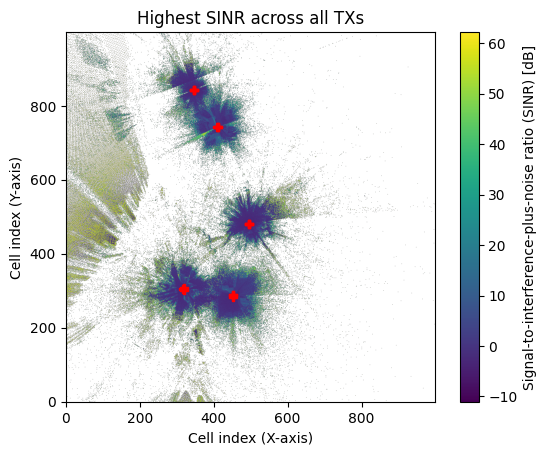

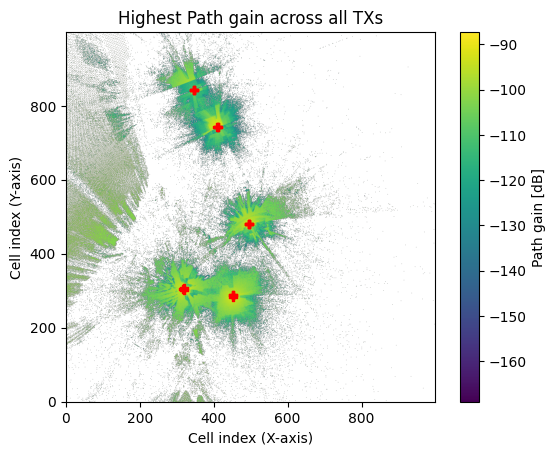

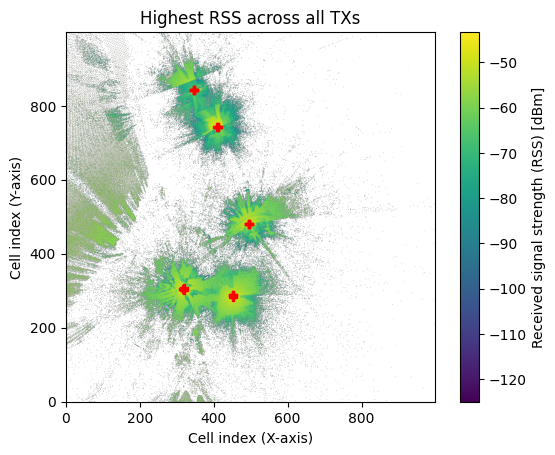

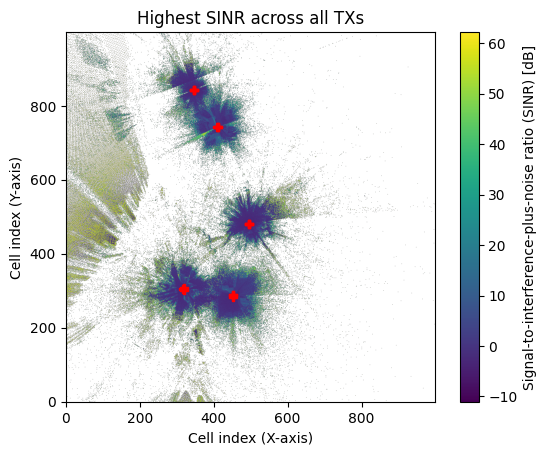

In [17]:
# Visualize path gain
rm.show(metric="path_gain")

# Visualize received signal strength (RSS)
rm.show(metric="rss")

# Visulaize SINR
rm.show(metric="sinr")

In [34]:
add_tx(scene, 'tx', latlon_to_xyz(48.71917, 2.25528))
# add_tx(scene, 'tx', [1000, 1000, 0])

In [36]:
scene.remove('tx')

In [8]:
scene.preview()
# scene.preview(radio_map=rm, rm_vmin=-200)

In [16]:
scene.objects

{'water': <sionna.rt.scene_object.SceneObject at 0x7626bf2c77d0>,
 'forest': <sionna.rt.scene_object.SceneObject at 0x762688dde510>,
 'roads': <sionna.rt.scene_object.SceneObject at 0x762688ddd750>,
 'railways': <sionna.rt.scene_object.SceneObject at 0x762688dd6dd0>,
 'buildings': <sionna.rt.scene_object.SceneObject at 0x762688dd8550>,
 'terrain': <sionna.rt.scene_object.SceneObject at 0x762688708b50>}

In [17]:
scene.get("water").radio_material

RadioMaterial eta_r=78.000
              sigma=2.500
              thickness=0.100
              scattering_coefficient=0.000
              xpd_coefficient=0.000